<a href="https://colab.research.google.com/github/zFonta/CEIA_Trabajos_Grupales/blob/main/B2_AMq_AprendizajeDeMaquina/F1_TP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Formula 1

## 0 Librerias y Setup

In [1]:
# import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
# from kagglehub import KaggleDatasetAdapter
import pandas as pd
import requests
import time
import numpy as np
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Entrenamiento modelos

### Levantamos los parquets post-EDA

In [2]:
# Exportar los dataframes a archivos parquet
train_data = pd.read_parquet('./data/train_data.parquet')
test_data = pd.read_parquet('./data/test_data.parquet')

In [3]:
train_data.isna().sum()

Driver                   0
LapNumber                0
Compound                 0
TyreLife                 0
Position                 0
Race                     0
Position_Change          0
Prev_TyreLife         1152
PitNextLap_fixed         0
duration_sector_1      205
duration_sector_2       19
i1_speed             10296
i2_speed               818
st_speed              5475
team_name                0
final_position           0
Air_Temp_Mean          981
Track_Temp_Mean        981
Wind_Speed_Mean        981
Humidity_Mean          981
Rainfall_Max           981
periodo                 28
dtype: int64

In [4]:
train_data.head()

,Driver,LapNumber,Compound,TyreLife,Position,Race,Position_Change,Prev_TyreLife,PitNextLap_fixed,duration_sector_1,duration_sector_2,i1_speed,i2_speed,st_speed,team_name,final_position,Air_Temp_Mean,Track_Temp_Mean,Wind_Speed_Mean,Humidity_Mean,Rainfall_Max,periodo
0,TSU,6,MEDIUM,6.0,8.0,Mexico City Grand Prix,-1.0,5.0,False,28.776,35.055,292.0,287.0,347.0,RB,17,26.405556,50.588272,1.847531,23.234568,0.0,2025-10-26
1,RUS,54,HARD,27.0,4.0,Singapore Grand Prix,2.0,26.0,False,28.698,41.495,295.0,267.0,287.0,Mercedes,6,30.786250,36.445625,0.955000,74.650000,0.0,2024-09-22
2,ZHO,36,MEDIUM,3.0,19.0,Azerbaijan Grand Prix,-3.0,2.0,False,38.838,43.822,NaN,211.0,317.0,Sauber,21,26.705921,44.349342,1.551316,38.019737,0.0,2024-09-15
3,LEC,39,MEDIUM,7.0,17.0,Austrian Grand Prix,2.0,6.0,False,17.343,31.572,309.0,228.0,308.0,Ferrari,3,29.425874,46.420979,1.667832,35.006993,1.0,2024-06-30
4,BEA,25,INTERMEDIATE,25.0,11.0,São Paulo Grand Prix,1.0,24.0,False,21.469,45.067,301.0,221.0,256.0,Haas,18,21.662687,25.769652,0.735821,85.258706,1.0,2024-11-03


In [5]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64642 entries, 0 to 64641
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Driver             64642 non-null  object 
 1   LapNumber          64642 non-null  int64  
 2   Compound           64642 non-null  object 
 3   TyreLife           64642 non-null  float64
 4   Position           64642 non-null  float64
 5   Race               64642 non-null  object 
 6   Position_Change    64642 non-null  float64
 7   Prev_TyreLife      63490 non-null  float64
 8   PitNextLap_fixed   64642 non-null  bool   
 9   duration_sector_1  64437 non-null  float64
 10  duration_sector_2  64623 non-null  float64
 11  i1_speed           54346 non-null  float64
 12  i2_speed           63824 non-null  float64
 13  st_speed           59167 non-null  float64
 14  team_name          64642 non-null  object 
 15  final_position     64642 non-null  int64  
 16  Air_Temp_Mean      636

In [6]:
train_data['PitNextLap_fixed'].value_counts(dropna=False, normalize=True)

PitNextLap_fixed
False    0.968225
True     0.031775
Name: proportion, dtype: float64

In [7]:
train_data.drop(['final_position', 'periodo'], 
                axis=1, 
                inplace=True)

In [9]:
# !pip install category_encoders

### Pipeline de transformaciones

In [8]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from category_encoders import WOEEncoder as CE_WOEEncoder

# ---- Separar X / y ANTES de detectar tipos (así el target no se cuela) ----
target_col = 'PitNextLap_fixed'
X = train_data.drop(columns=[target_col])
y = train_data[target_col]

columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numéricas:", columnas_numericas)
print("Categóricas:", columnas_categoricas)

# ---- Sub-pipeline numérico: PRIMERO imputa, DESPUÉS escala (en secuencia) ----
pipeline_numerico = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),   # missing_values=np.nan es el default
    ('scale', StandardScaler()),
])

# ---- Preprocesador combinado ----
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', CE_WOEEncoder(), columnas_categoricas),
        ('num', pipeline_numerico, columnas_numericas),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# ---- Pipeline completo ----
pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
])

# ---- Aplicar ----
X_transformado = pipeline.fit_transform(X, y)

# ---- Convertir a DataFrame ----
nombres_cols = pipeline.named_steps['preprocesamiento'].get_feature_names_out()
df_transformado = pd.DataFrame(X_transformado, columns=nombres_cols, index=X.index)

df_transformado.head()

Numéricas: ['LapNumber', 'TyreLife', 'Position', 'Position_Change', 'Prev_TyreLife', 'duration_sector_1', 'duration_sector_2', 'i1_speed', 'i2_speed', 'st_speed', 'Air_Temp_Mean', 'Track_Temp_Mean', 'Wind_Speed_Mean', 'Humidity_Mean', 'Rainfall_Max']
Categóricas: ['Driver', 'Compound', 'Race', 'team_name']


,Driver,Compound,Race,team_name,LapNumber,TyreLife,Position,Position_Change,Prev_TyreLife,duration_sector_1,duration_sector_2,i1_speed,i2_speed,st_speed,Air_Temp_Mean,Track_Temp_Mean,Wind_Speed_Mean,Humidity_Mean,Rainfall_Max
0,-0.000899,0.234821,-0.281748,-0.037917,-1.355254,-0.822800,-0.330117,-0.281786,-0.921639,0.051580,-0.043629,0.834599,0.871410,1.714428,0.564754,1.726537,0.089876,-1.936083,-0.544376
1,-0.050785,-0.512749,-0.478316,-0.019378,1.312175,1.227750,-1.069118,0.513199,1.174226,0.040304,0.864951,0.905856,0.417452,-0.384386,1.505805,0.091993,-1.035945,1.318123,-0.544376
2,0.100949,0.234821,-0.457194,-0.004223,0.311889,-1.115736,1.702137,-0.811777,-1.221048,1.506248,1.193254,0.000000,-0.853631,0.665021,0.629278,1.005469,-0.283764,-1.000294,-0.544376
3,-0.063997,0.234821,0.121501,-0.048964,0.478604,-0.725155,1.332636,0.513199,-0.821836,-1.601294,-0.535024,1.238385,-0.467766,0.350199,1.213572,1.244900,-0.136793,-1.190978,1.865271
4,-0.079025,0.480121,0.206162,0.057563,-0.299396,1.032459,0.224134,0.248204,0.974620,-1.004796,1.368903,1.048368,-0.626652,-1.468773,-0.454098,-1.141887,-1.312413,1.989573,1.865271


In [9]:
df_transformado['PitNextLap_fixed']=train_data['PitNextLap_fixed']

In [10]:
df_transformado['PitNextLap_fixed']

0        False
1        False
2        False
3        False
4        False
         ...  
64637    False
64638    False
64639    False
64640    False
64641    False
Name: PitNextLap_fixed, Length: 64642, dtype: bool

### Baseline

In [ ]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class HeuristicaPitStop(BaseEstimator, ClassifierMixin):
    """
    Baseline SIN machine learning para predecir parada en boxes.
    Regla de dominio: el neumático se degrada con las vueltas, así que predice
    parada en la próxima vuelta cuando la antigüedad del neumático supera un
    umbral. Usa una sola columna e ignora el resto.
    """
    def __init__(self, columna_antiguedad='TyreLife', umbral=20, escala=5):
        self.columna_antiguedad = columna_antiguedad
        self.umbral = umbral
        self.escala = escala

    def fit(self, X, y=None):
        # No aprende nada; solo cumple la interfaz de sklearn para encajar
        # en tu dict de modelos y en los loops de evaluación.
        self.classes_ = np.array([False, True])
        return self

    def _antiguedad(self, X):
        return np.asarray(X[self.columna_antiguedad], dtype=float)

    def predict(self, X):
        return self._antiguedad(X) >= self.umbral

    def predict_proba(self, X):
        # Score monótono en la antigüedad (logística centrada en el umbral, cruza
        # 0.5 justo en umbral). Para la curva PR/AP solo importa el ORDEN, así que
        # la curva refleja exactamente el poder de ranking de la antigüedad.
        s = self._antiguedad(X)
        p_pos = 1 / (1 + np.exp(-(s - self.umbral) / self.escala))
        return np.column_stack([1 - p_pos, p_pos])

In [ ]:
from sklearn.metrics import classification_report

target_col = 'PitNextLap_fixed'
X_test = test_data.drop(columns=[target_col])
y_test = test_data[target_col]

heuristica = HeuristicaPitStop(columna_antiguedad='TyreLife', umbral=20)
y_pred = heuristica.predict(X_test)          # no necesita fit
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

       False       0.98      0.74      0.84      6938
        True       0.06      0.50      0.11       245

    accuracy                           0.73      7183
   macro avg       0.52      0.62      0.48      7183
weighted avg       0.95      0.73      0.82      7183



### Regresión logística

In [ ]:
import os
import joblib
from sklearn.linear_model import LogisticRegression
from optimize import train_with_optuna

# 'liblinear' soporta l1 y l2 (ideal para binario) y class_weight,
# así TODAS las combinaciones de la grilla son válidas.
model = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)

params = {
    'C': {'low': 1e-4, 'high': 100, 'log': True},   # fuerza de regularización (escala log)
    'penalty': ['l1', 'l2'],                          # tipo de regularización
    'class_weight': ['balanced', None],              # clave por el desbalanceo del target
}

best_model_logistic, results_df = train_with_optuna(train = df_transformado,
                                                     target_col = 'PitNextLap_fixed',
                                                     classifier = model,
                                                     param_grid = params,
                                                     scoring = 'f1_macro',
                                                     n_trials = 50,
                                                     n_folds = 5,
                                                     random_state = 42)

os.makedirs('./modelos', exist_ok=True)
joblib.dump(best_model_logistic, './modelos/logistic_regression_best_trial.joblib')

c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[W 2026-06-21 18:51:12,842] Trial 0 failed with parameters: {'C': 0.017670169402947963, 'penalty': 'l1', 'class_weight': 'balanced'} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\Administrator\Documents\GitHub\CEIA_Trabajos_Grupales\B2_AMq_AprendizajeDeMaquina\optimize.py", line 113, in objective
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

### Random Forest

In [13]:
from optimize import train_with_optuna
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, n_jobs=-1)

params = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.7],
    'class_weight': ['balanced', 'balanced_subsample']
}

best_model_rf, results_df = train_with_optuna(train = df_transformado,
                                           target_col = 'PitNextLap_fixed',
                                           classifier = model,
                                           param_grid = params,
                                           scoring='f1_macro',
                                           n_trials = 50,
                                           n_folds = 5,
                                           random_state = 42)

joblib.dump(best_model_rf, './modelos/random_forest_best_trial.joblib')

c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Mejor trial: #36
   Score (f1_macro): 0.6633
   Parámetros: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 0.7, 'class_weight': 'balanced_subsample'}


['./modelos/random_forest_best_trial.joblib']

### LGBM

In [14]:
import joblib
from optimize import train_with_optuna
from lightgbm import LGBMClassifier

model = LGBMClassifier(random_state=42)
params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

best_model_lgbm, results_df = train_with_optuna(train = df_transformado,
                                           target_col = 'PitNextLap_fixed',
                                           classifier = model,
                                           param_grid = params,
                                           scoring='f1_macro',
                                           n_trials = 50,
                                           n_folds = 5,
                                           random_state = 42)

joblib.dump(best_model_lgbm, './modelos/lgbm_best_trial.joblib')

[LightGBM] [Info] Number of positive: 2054, number of negative: 62588
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004361 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1673
[LightGBM] [Info] Number of data points in the train set: 64642, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031775 -> initscore=-3.416784
[LightGBM] [Info] Start training from score -3.416784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
✅ Mejor trial: #2
   Score (f1_macro): 0.6635
   Parámetros: {'n_estimators': 300, 'learning_rate': 0.1, 'num_leaves': 63, 'max_depth': 10, 'min_child_samples': 20, 'subsample': 0.7, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1}


['./modelos/lgbm_best_trial.joblib']

### XGBoost

In [15]:
# !pip install xgboost

In [16]:
from optimize import train_with_optuna
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

best_model_xgboost, results_df = train_with_optuna(train = df_transformado,
                                           target_col = 'PitNextLap_fixed',
                                           classifier = model,
                                           param_grid = params,
                                           scoring='f1_macro',
                                           n_trials = 20,
                                           n_folds = 5,
                                           random_state = 42)

joblib.dump(best_model_xgboost, './modelos/xgboost_best_trial.joblib')

c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:03:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Mejor trial: #10
   Score (f1_macro): 0.6576
   Parámetros: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.7, 'gamma': 0, 'reg_alpha': 1, 'reg_lambda': 0.1}


['./modelos/xgboost_best_trial.joblib']

### Catboost

In [ ]:
# !pip install catboost

     -------------------------------------- 100.2/100.2 MB 4.9 MB/s eta 0:00:00
     ---------------------------------------- 47.3/47.3 kB ? eta 0:00:00
     ---------------------------------------- 9.9/9.9 MB 48.7 MB/s eta 0:00:00
     ------------------------------------- 454.8/454.8 kB 27.8 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
df_transformado

,Driver,Compound,Race,team_name,LapNumber,TyreLife,Position,Position_Change,Prev_TyreLife,duration_sector_1,duration_sector_2,i1_speed,i2_speed,st_speed,Air_Temp_Mean,Track_Temp_Mean,Wind_Speed_Mean,Humidity_Mean,Rainfall_Max,PitNextLap_fixed
0,-0.000899,0.234821,-0.281748,-0.037917,-1.355254,-0.822800,-0.330117,-0.281786,-0.921639,0.051580,-0.043629,0.834599,0.871410,1.714428,0.564754,1.726537,0.089876,-1.936083,-0.544376,False
1,-0.050785,-0.512749,-0.478316,-0.019378,1.312175,1.227750,-1.069118,0.513199,1.174226,0.040304,0.864951,0.905856,0.417452,-0.384386,1.505805,0.091993,-1.035945,1.318123,-0.544376,False
2,0.100949,0.234821,-0.457194,-0.004223,0.311889,-1.115736,1.702137,-0.811777,-1.221048,1.506248,1.193254,0.000000,-0.853631,0.665021,0.629278,1.005469,-0.283764,-1.000294,-0.544376,False
3,-0.063997,0.234821,0.121501,-0.048964,0.478604,-0.725155,1.332636,0.513199,-0.821836,-1.601294,-0.535024,1.238385,-0.467766,0.350199,1.213572,1.244900,-0.136793,-1.190978,1.865271,False
4,-0.079025,0.480121,0.206162,0.057563,-0.299396,1.032459,0.224134,0.248204,0.974620,-1.004796,1.368903,1.048368,-0.626652,-1.468773,-0.454098,-1.141887,-1.312413,1.989573,1.865271,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64637,0.155793,0.234821,0.156892,0.070594,-1.466396,-1.018091,1.517387,0.248204,-1.121245,-0.268354,-1.013299,0.715839,0.576338,-0.104544,-1.024827,-0.559823,3.522213,0.451700,-0.544376,False
64638,-0.063997,-0.512749,-0.021824,-0.048964,1.923461,1.130104,-1.069118,-0.016791,1.074423,-1.055540,-1.536438,0.000000,0.689827,0.455140,-1.127002,-0.584402,0.209006,0.637808,-0.544376,False
64639,0.082971,-0.512749,-0.265868,0.041220,1.812318,3.180654,0.778385,-1.871757,3.170288,-1.130139,0.242912,-1.635618,-1.443777,-0.524307,-0.336660,0.886214,-1.005199,-0.082617,-0.544376,False
64640,-0.021397,0.382086,0.215739,-0.048964,-1.466396,-0.725155,-1.069118,-0.016791,-0.821836,0.400862,1.120454,0.000000,-0.149996,0.665021,0.785183,-0.536023,-1.378751,-2.046065,-0.544376,False


In [19]:
# CatBoost
from optimize import train_with_optuna
from catboost import CatBoostClassifier

model = CatBoostClassifier(random_state=42, verbose=0)

params = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 10],
    'auto_class_weights': ['Balanced', 'SqrtBalanced'],
    'od_type': ['Iter'],
    'od_wait': [20]
}

best_model_catboost, results_df = train_with_optuna(train = df_transformado,
                                           target_col = 'PitNextLap_fixed',
                                           classifier = model,
                                           param_grid = params,
                                           scoring='f1_macro',
                                           n_trials = 50,
                                           n_folds = 5,
                                           random_state = 42)

joblib.dump(best_model_catboost, './modelos/catboost_best_trial.joblib')

c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Administrator\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, No

✅ Mejor trial: #8
   Score (f1_macro): 0.6936
   Parámetros: {'iterations': 300, 'learning_rate': 0.1, 'depth': 6, 'l2_leaf_reg': 1, 'auto_class_weights': 'SqrtBalanced', 'od_type': 'Iter', 'od_wait': 20}


['./modelos/catboost_best_trial.joblib']

# Validación

In [12]:
from sklearn.metrics import classification_report

--- RENDIMIENTO: HEURÍSTICA ---
PR-AUC: 0.0554
Umbral Óptimo sugerido: 0.022 (Max F1-Score: 0.120)



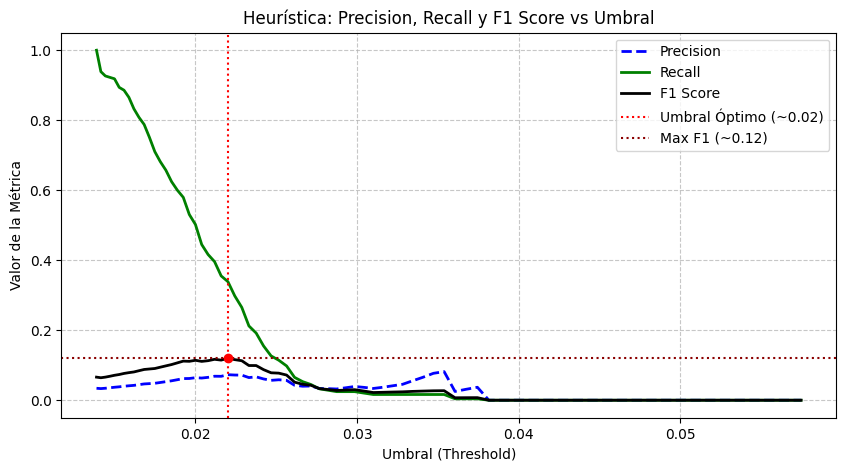


--- Reporte de Clasificación (Heurística - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.97      0.85      0.91      6938
        True       0.07      0.34      0.12       245

    accuracy                           0.83      7183
   macro avg       0.52      0.59      0.51      7183
weighted avg       0.94      0.83      0.88      7183



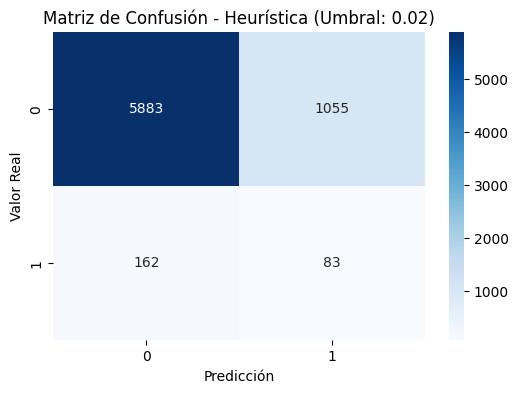

--- RENDIMIENTO: LOGÍSTICA ---
PR-AUC: 0.1397
Umbral Óptimo sugerido: 0.079 (Max F1-Score: 0.222)



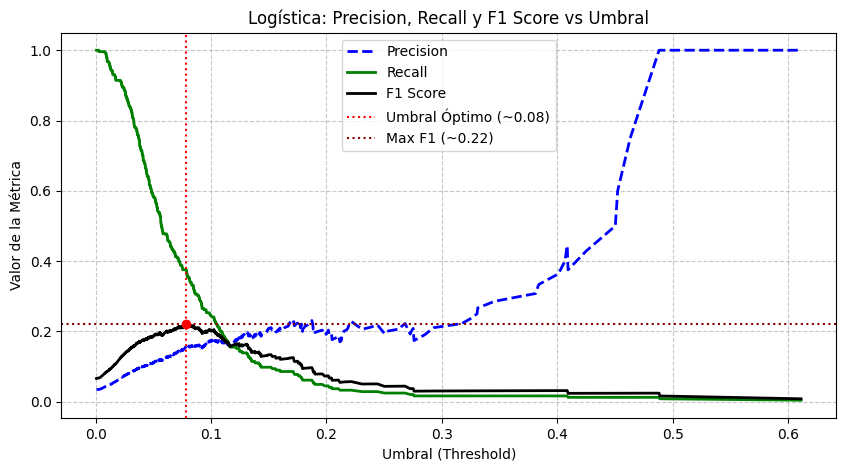


--- Reporte de Clasificación (Logística - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.98      0.93      0.95      6938
        True       0.16      0.38      0.22       245

    accuracy                           0.91      7183
   macro avg       0.57      0.65      0.59      7183
weighted avg       0.95      0.91      0.93      7183



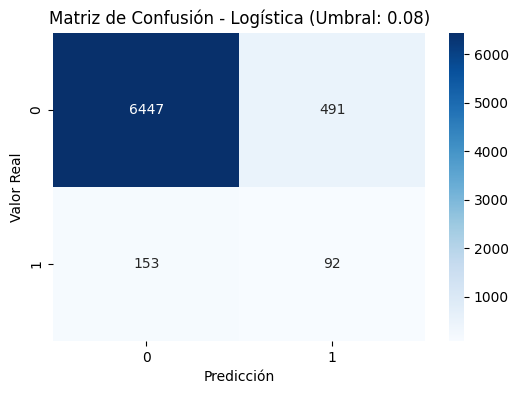

--- RENDIMIENTO: RANDOM FOREST ---
PR-AUC: 0.4031
Umbral Óptimo sugerido: 0.350 (Max F1-Score: 0.464)



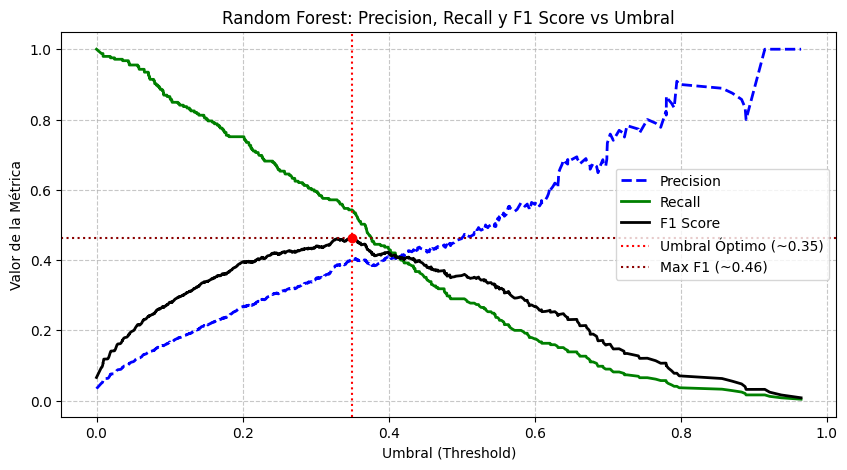


--- Reporte de Clasificación (Random Forest - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.98      0.97      0.98      6938
        True       0.41      0.54      0.46       245

    accuracy                           0.96      7183
   macro avg       0.69      0.76      0.72      7183
weighted avg       0.96      0.96      0.96      7183



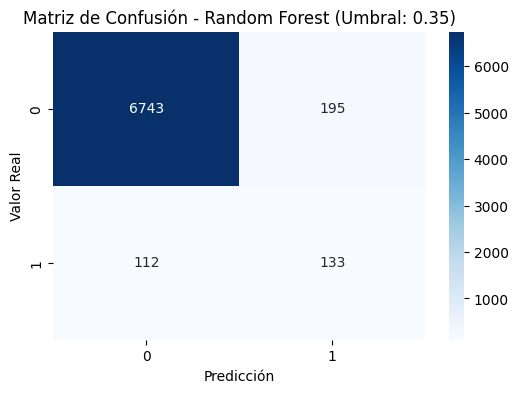

--- RENDIMIENTO: LIGHTGBM ---
PR-AUC: 0.5068
Umbral Óptimo sugerido: 0.175 (Max F1-Score: 0.498)



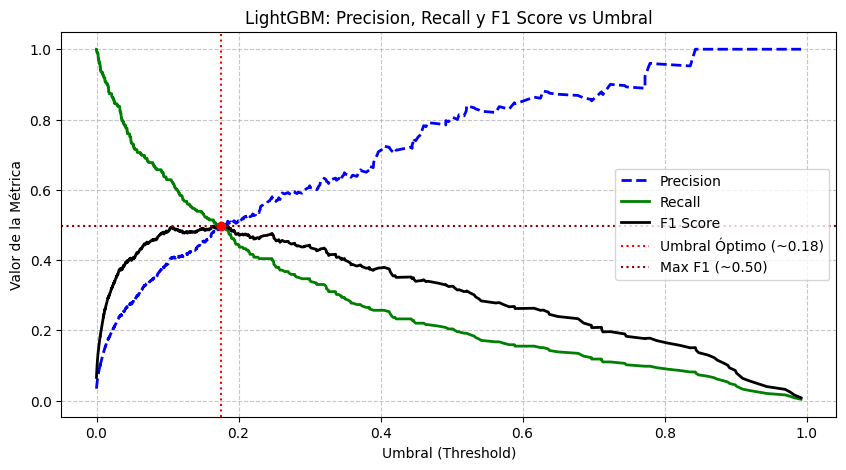


--- Reporte de Clasificación (LightGBM - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.98      0.98      0.98      6938
        True       0.50      0.50      0.50       245

    accuracy                           0.97      7183
   macro avg       0.74      0.74      0.74      7183
weighted avg       0.97      0.97      0.97      7183



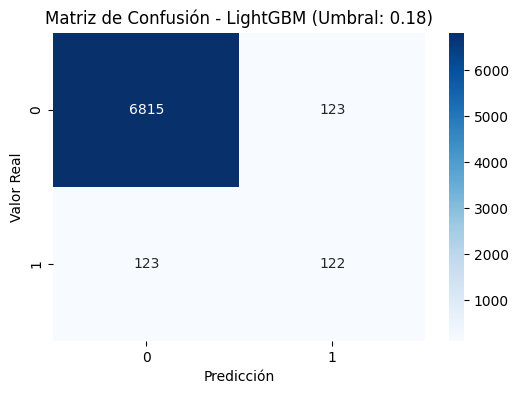

--- RENDIMIENTO: XGBOOST ---
PR-AUC: 0.5213
Umbral Óptimo sugerido: 0.157 (Max F1-Score: 0.491)



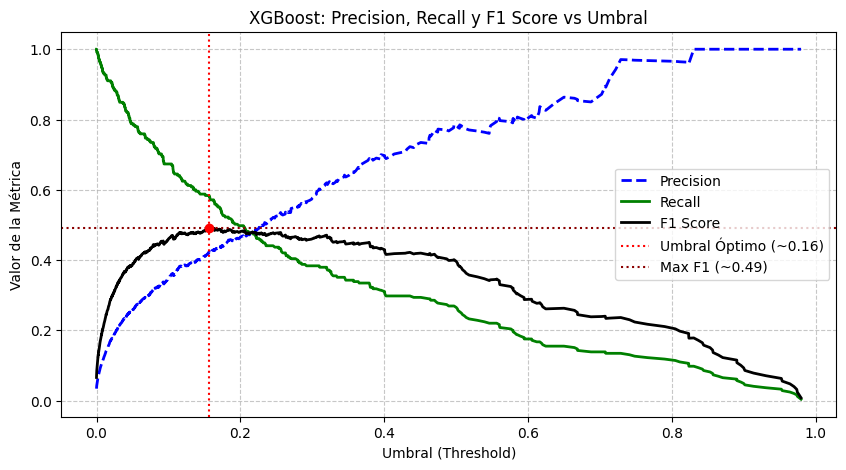


--- Reporte de Clasificación (XGBoost - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.99      0.97      0.98      6938
        True       0.42      0.58      0.49       245

    accuracy                           0.96      7183
   macro avg       0.70      0.78      0.73      7183
weighted avg       0.97      0.96      0.96      7183



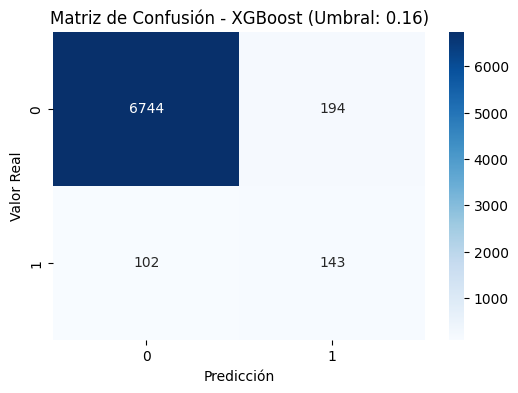

--- RENDIMIENTO: CATBOOST ---
PR-AUC: 0.4814
Umbral Óptimo sugerido: 0.534 (Max F1-Score: 0.489)



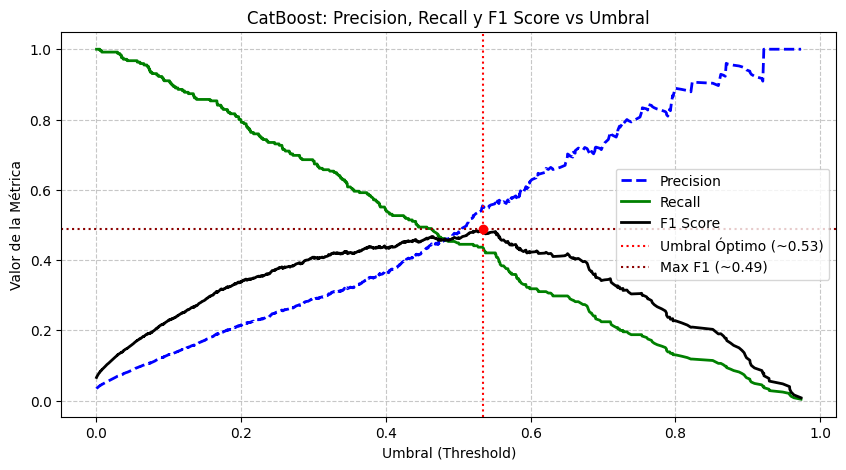


--- Reporte de Clasificación (CatBoost - Umbral Ajustado) ---
              precision    recall  f1-score   support

       False       0.98      0.99      0.98      6938
        True       0.55      0.44      0.49       245

    accuracy                           0.97      7183
   macro avg       0.77      0.71      0.74      7183
weighted avg       0.97      0.97      0.97      7183



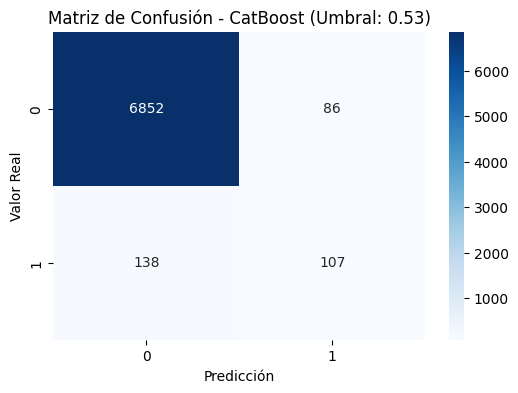

In [14]:
import joblib
import pandas as pd
import seaborn as sns
from evaluation import evaluate_model_pr
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    classification_report
)

# ---- Transformar el test UNA vez (sin y) y reconstruir DataFrame ----
nombres_cols = pipeline.named_steps['preprocesamiento'].get_feature_names_out()
X_test_arr = pipeline.transform(test_data.drop('PitNextLap_fixed', axis=1))
X_transformado_test = pd.DataFrame(X_test_arr, columns=nombres_cols, index=test_data.index)

y_test = test_data['PitNextLap_fixed'].values

# ---- Cargar todos los modelos ----
modelos = {
    "Heurística":    HeuristicaPitStop(columna_antiguedad='TyreLife', umbral=20),
    "Logística":     joblib.load('./modelos/logistic_regression_best_trial.joblib'),
    "Random Forest": joblib.load('./modelos/random_forest_best_trial.joblib'),
    "LightGBM":      joblib.load('./modelos/lgbm_best_trial.joblib'),
    "XGBoost":       joblib.load('./modelos/xgboost_best_trial.joblib'),
    "CatBoost":      joblib.load('./modelos/catboost_best_trial.joblib'),
}

# ---- Evaluar todos ----
for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict_proba(X_transformado_test)
    evaluate_model_pr(y_true=y_test, y_pred_proba=y_pred_proba[:,1], model_name=nombre)




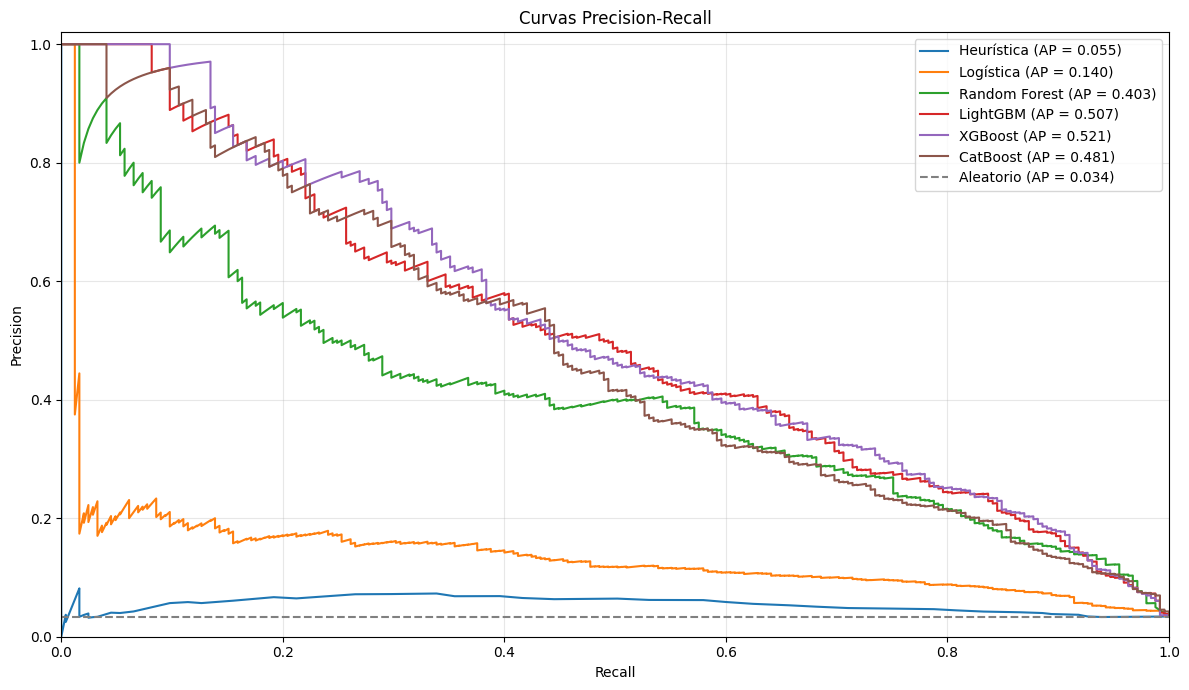

In [15]:
import matplotlib.pyplot as plt

fig, ax_pr = plt.subplots(figsize=(12, 7))

# Baseline de PR = prevalencia de la clase positiva (clasificador sin skill)
prevalencia = y_test.mean()

for nombre, modelo in modelos.items():
    y_score = modelo.predict_proba(X_transformado_test)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    ax_pr.plot(recall, precision, label=f"{nombre} (AP = {ap:.3f})")

# Línea de referencia (modelo aleatorio)
ax_pr.axhline(prevalencia, linestyle='--', color='grey',
              label=f'Aleatorio (AP = {prevalencia:.3f})')

ax_pr.set(title='Curvas Precision-Recall', xlabel='Recall',
          ylabel='Precision', xlim=(0, 1), ylim=(0, 1.02))
ax_pr.legend(loc='upper right')
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, precision_recall_curve
# to_markdown() necesita tabulate:  pip install tabulate

# Umbrales que usaste por modelo. Si dejás None, se calcula el que maximiza F1 de la clase positiva.
umbrales = {
    "Logística": None,
    "Random Forest": None,
    "LightGBM": None,
    "XGBoost": None,
    "CatBoost": None,
}

def umbral_optimo_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    return thresholds[np.argmax(f1)]

filas = []
for nombre, modelo in modelos.items():
    y_score = modelo.predict_proba(X_transformado_test)[:, 1]

    th = umbrales.get(nombre)
    if th is None:
        th = umbral_optimo_f1(y_test, y_score)

    y_pred = y_score >= th  # booleano, coincide con y_test
    rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # detecta las claves de clase automáticamente (sirve para True/False o 1/0)
    agg = {"accuracy", "macro avg", "weighted avg"}
    neg, pos = sorted(k for k in rep if k not in agg)

    filas.append({
        "Modelo": nombre,
        "Umbral": th,
        "Accuracy": rep["accuracy"],
        "Macro F1": rep["macro avg"]["f1-score"],
        "P (True)": rep[pos]["precision"],
        "R (True)": rep[pos]["recall"],
        "F1 (True)": rep[pos]["f1-score"],
        # "P (False)": rep[neg]["precision"],
        # "R (False)": rep[neg]["recall"],
        # "F1 (False)": rep[neg]["f1-score"],

        # "Weighted F1": rep["weighted avg"]["f1-score"],
    })

tabla = pd.DataFrame(filas).round(3)
print(tabla.to_markdown(index=False))

| Modelo        |   Umbral |   Accuracy |   Macro F1 |   P (True) |   R (True) |   F1 (True) |
|:--------------|---------:|-----------:|-----------:|-----------:|-----------:|------------:|
| Logística     |    0.079 |      0.91  |      0.587 |      0.158 |      0.376 |       0.222 |
| Random Forest |    0.35  |      0.957 |      0.721 |      0.405 |      0.543 |       0.464 |
| LightGBM      |    0.175 |      0.966 |      0.74  |      0.498 |      0.498 |       0.498 |
| XGBoost       |    0.157 |      0.959 |      0.735 |      0.424 |      0.584 |       0.491 |
| CatBoost      |    0.534 |      0.969 |      0.736 |      0.554 |      0.437 |       0.489 |


| Modelo        |   Umbral |   Accuracy |   Macro F1 |   P (True) |   R (True) |   F1 (True) |
|:--------------|---------:|-----------:|-----------:|-----------:|-----------:|------------:|
| Logística     |    0.079 |      0.91  |      0.587 |      0.158 |      0.376 |       0.222 |
| Random Forest |    0.35  |      0.957 |      0.721 |      0.405 |      0.543 |       0.464 |
| LightGBM      |    0.175 |      0.966 |      0.74  |      0.498 |      0.498 |       0.498 |
| XGBoost       |    0.157 |      0.959 |      0.735 |      0.424 |      0.584 |       0.491 |
| CatBoost      |    0.534 |      0.969 |      0.736 |      0.554 |      0.437 |       0.489 |

# Conclusiones

Los modeos no son muy buenos en general, les cuesta clasificar la clase minoritaria.
Deberíamos disponer de datos adicionales de otras fuentes para conseguir una performance mejor.
Como no se hizo un tratamiento exhaustivo de los datos categóricos, el catboost da muy bien.
Se presenta como evidente que incluir el peso de las clases es insuficiente para tratar el desbalanceo. Se debería ahondar en otras técnicas de balanceo.
Los modelos basados en árboles muestran una mayor performance predictiva que los modelos basados en la estadística clásicas, al poder captar patrones más complejos.